First 5 Rows:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



Dataset Shape:
(150, 5)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB

Missing Values:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Class Distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Features:


,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2



Target:


0    setosa
1    setosa
2    setosa
3    setosa
4    setosa
Name: species, dtype: str


Training Shape:
(120, 4)

Testing Shape:
(30, 4)

Actual vs Predicted:


,Actual,Predicted
0,setosa,setosa
1,virginica,virginica
2,versicolor,versicolor
3,versicolor,versicolor
4,setosa,setosa
5,versicolor,versicolor
6,setosa,setosa
7,setosa,setosa
8,virginica,virginica
9,versicolor,versicolor



========== BASELINE RANDOM FOREST ==========
Accuracy : 0.9
Precision: 0.9023569023569024
Recall   : 0.9
F1 Score : 0.8997493734335839

Baseline Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  2  8]]

Baseline Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30


Baseline Feature Importance:


,Feature,Importance
3,petal_width,0.437185
2,petal_length,0.431466
0,sepal_length,0.116349
1,sepal_width,0.015000


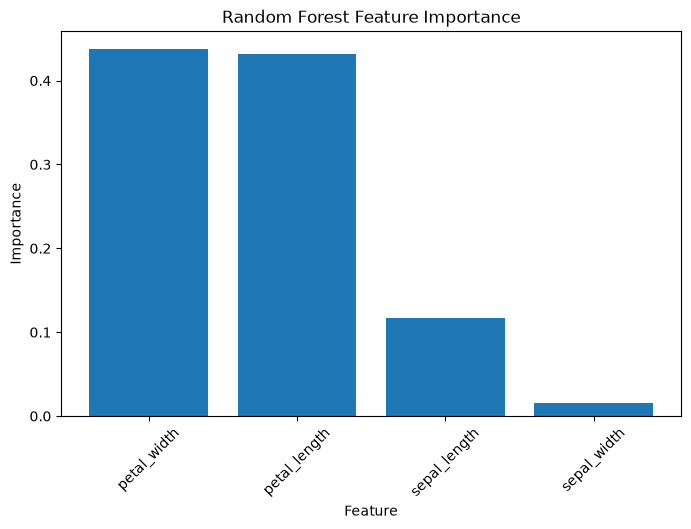


Cross Validation Scores:
[0.96666667 0.96666667 0.93333333 0.96666667 1.        ]

Mean Cross Validation Accuracy:
0.9666666666666668

Best Parameters:
{'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}

Best Cross Validation Score:
0.9581699346405228

========== TUNED RANDOM FOREST ==========
Accuracy : 0.9666666666666667
Precision: 0.9696969696969696
Recall   : 0.9666666666666667
F1 Score : 0.9665831244778613

Tuned Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

Tuned Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30


Tuned Model Feature Importance:


,Feature,Importance
2,petal_length,0.444206
3,petal_width,0.435467
0,sepal_length,0.114296
1,sepal_width,0.006031



Baseline vs Tuned Random Forest:


,Model,Accuracy,Precision,Recall,F1 Score
0,Baseline Random Forest,0.900000,0.902357,0.900000,0.899749
1,Tuned Random Forest,0.966667,0.969697,0.966667,0.966583



========== FINAL RESULTS ==========

Baseline Random Forest:
Accuracy : 0.9
Precision: 0.9023569023569024
Recall   : 0.9
F1 Score : 0.8997493734335839

5-Fold Cross Validation Scores:
[0.96666667 0.96666667 0.93333333 0.96666667 1.        ]
Mean CV Accuracy:
0.9666666666666668

Best Hyperparameters:
{'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}

Tuned Random Forest:
Accuracy : 0.9666666666666667
Precision: 0.9696969696969696
Recall   : 0.9666666666666667
F1 Score : 0.9665831244778613

Random Forest Task Completed Successfully.


In [1]:
# =========================================================
# LEVEL 3 - TASK 1: RANDOM FOREST CLASSIFICATION
# IRIS DATASET
# =========================================================


# =========================================================
# 1. IMPORT LIBRARIES
# =========================================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV
)

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


# =========================================================
# 2. LOAD THE DATASET
# =========================================================

df = pd.read_csv("dataset/1) iris.csv")


# =========================================================
# 3. EXPLORE THE DATASET
# =========================================================

print("First 5 Rows:")
display(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nClass Distribution:")
print(df["species"].value_counts())


# =========================================================
# 4. SEPARATE FEATURES AND TARGET
# =========================================================

X = df.drop(columns=["species"])
y = df["species"]

print("\nFeatures:")
display(X.head())

print("\nTarget:")
display(y.head())


# =========================================================
# 5. TRAIN / TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Shape:")
print(X_train.shape)

print("\nTesting Shape:")
print(X_test.shape)


# =========================================================
# 6. CREATE BASELINE RANDOM FOREST MODEL
# =========================================================

baseline_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)


# =========================================================
# 7. TRAIN BASELINE MODEL
# =========================================================

baseline_model.fit(
    X_train,
    y_train
)


# =========================================================
# 8. MAKE BASELINE PREDICTIONS
# =========================================================

baseline_y_pred = baseline_model.predict(
    X_test
)


# =========================================================
# 9. ACTUAL VS PREDICTED
# =========================================================

baseline_comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": baseline_y_pred
})

print("\nActual vs Predicted:")
display(baseline_comparison.head(10))


# =========================================================
# 10. EVALUATE BASELINE MODEL
# =========================================================

baseline_accuracy = accuracy_score(
    y_test,
    baseline_y_pred
)

baseline_precision = precision_score(
    y_test,
    baseline_y_pred,
    average="weighted"
)

baseline_recall = recall_score(
    y_test,
    baseline_y_pred,
    average="weighted"
)

baseline_f1 = f1_score(
    y_test,
    baseline_y_pred,
    average="weighted"
)

print("\n========== BASELINE RANDOM FOREST ==========")

print("Accuracy :", baseline_accuracy)
print("Precision:", baseline_precision)
print("Recall   :", baseline_recall)
print("F1 Score :", baseline_f1)


# =========================================================
# 11. BASELINE CONFUSION MATRIX
# =========================================================

baseline_cm = confusion_matrix(
    y_test,
    baseline_y_pred
)

print("\nBaseline Confusion Matrix:")
print(baseline_cm)


# =========================================================
# 12. BASELINE CLASSIFICATION REPORT
# =========================================================

print("\nBaseline Classification Report:")

print(
    classification_report(
        y_test,
        baseline_y_pred
    )
)


# =========================================================
# 13. FEATURE IMPORTANCE - BASELINE MODEL
# =========================================================

baseline_feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": baseline_model.feature_importances_
})

baseline_feature_importance = baseline_feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nBaseline Feature Importance:")
display(baseline_feature_importance)


# =========================================================
# 14. PLOT FEATURE IMPORTANCE
# =========================================================

plt.figure(figsize=(8, 5))

plt.bar(
    baseline_feature_importance["Feature"],
    baseline_feature_importance["Importance"]
)

plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Random Forest Feature Importance")

plt.xticks(rotation=45)

plt.show()


# =========================================================
# 15. CROSS VALIDATION
# =========================================================

cv_scores = cross_val_score(
    baseline_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("\nCross Validation Scores:")
print(cv_scores)

print("\nMean Cross Validation Accuracy:")
print(cv_scores.mean())


# =========================================================
# 16. DEFINE HYPERPARAMETER GRID
# =========================================================

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 3, 5],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}


# =========================================================
# 17. CREATE GRID SEARCH
# =========================================================

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42
    ),
    param_grid=param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)


# =========================================================
# 18. RUN HYPERPARAMETER TUNING
# =========================================================

grid_search.fit(
    X_train,
    y_train
)


# =========================================================
# 19. DISPLAY BEST PARAMETERS
# =========================================================

print("\nBest Parameters:")
print(grid_search.best_params_)

print("\nBest Cross Validation Score:")
print(grid_search.best_score_)


# =========================================================
# 20. GET BEST MODEL
# =========================================================

best_model = grid_search.best_estimator_


# =========================================================
# 21. MAKE PREDICTIONS WITH BEST MODEL
# =========================================================

best_y_pred = best_model.predict(
    X_test
)


# =========================================================
# 22. EVALUATE TUNED MODEL
# =========================================================

best_accuracy = accuracy_score(
    y_test,
    best_y_pred
)

best_precision = precision_score(
    y_test,
    best_y_pred,
    average="weighted"
)

best_recall = recall_score(
    y_test,
    best_y_pred,
    average="weighted"
)

best_f1 = f1_score(
    y_test,
    best_y_pred,
    average="weighted"
)

print("\n========== TUNED RANDOM FOREST ==========")

print("Accuracy :", best_accuracy)
print("Precision:", best_precision)
print("Recall   :", best_recall)
print("F1 Score :", best_f1)


# =========================================================
# 23. TUNED CONFUSION MATRIX
# =========================================================

best_cm = confusion_matrix(
    y_test,
    best_y_pred
)

print("\nTuned Confusion Matrix:")
print(best_cm)


# =========================================================
# 24. TUNED CLASSIFICATION REPORT
# =========================================================

print("\nTuned Classification Report:")

print(
    classification_report(
        y_test,
        best_y_pred
    )
)


# =========================================================
# 25. FEATURE IMPORTANCE - TUNED MODEL
# =========================================================

best_feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

best_feature_importance = best_feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nTuned Model Feature Importance:")
display(best_feature_importance)


# =========================================================
# 26. COMPARE BASELINE VS TUNED MODEL
# =========================================================

model_comparison = pd.DataFrame({
    "Model": [
        "Baseline Random Forest",
        "Tuned Random Forest"
    ],
    "Accuracy": [
        baseline_accuracy,
        best_accuracy
    ],
    "Precision": [
        baseline_precision,
        best_precision
    ],
    "Recall": [
        baseline_recall,
        best_recall
    ],
    "F1 Score": [
        baseline_f1,
        best_f1
    ]
})

print("\nBaseline vs Tuned Random Forest:")
display(model_comparison)


# =========================================================
# 27. FINAL SUMMARY
# =========================================================

print("\n========== FINAL RESULTS ==========")

print("\nBaseline Random Forest:")
print("Accuracy :", baseline_accuracy)
print("Precision:", baseline_precision)
print("Recall   :", baseline_recall)
print("F1 Score :", baseline_f1)

print("\n5-Fold Cross Validation Scores:")
print(cv_scores)

print("Mean CV Accuracy:")
print(cv_scores.mean())

print("\nBest Hyperparameters:")
print(grid_search.best_params_)

print("\nTuned Random Forest:")
print("Accuracy :", best_accuracy)
print("Precision:", best_precision)
print("Recall   :", best_recall)
print("F1 Score :", best_f1)

print(
    "\nRandom Forest Task Completed Successfully."
)